## Convolutional neural network using embeddings to predict log binding affinity

### Load the data:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
from transformers import AutoTokenizer, AutoModel, EsmTokenizer, EsmModel
from tqdm import tqdm

2025-02-10 13:55:37.225080: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-10 13:55:38.307947: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /local/java/cuda-11.6.0/lib64/:/local/java/cudnn-linux-x86_64-8.5.0.96_cuda11-archive/lib/:/local/java/cuda-12.6.2/lib64/:/local/java/cudnn-linux-x86_64-9.5.1.17_cuda12-archive/lib/
2025-02-10 13:55:38.308024: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared objec

In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Preprocess the data
data = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
data = data[~data['Protein_FASTA'].str.contains('X')] # remove complexes with ambiguous char in FASTA string
toDrop = ['4yx4', '1laf', '4buq', '1k22', '1hmt', '1utn', '4rux', '1bty']
data = data[~data['PDB_Code'].isin(toDrop)]
# data = data.reset_index()
# display(data)

In [5]:
# To generate embeddings, need list of FASTA and list of SMILES
protein_fastas = data['Protein_FASTA'].tolist()
ligand_SMILES = data['Ligand_SMILES'].tolist()

# Load protein embedding model (ESM2)
esm_model_name = "facebook/esm2_t12_35M_UR50D"
esm_tokenizer = EsmTokenizer.from_pretrained(esm_model_name)
esm_model = EsmModel.from_pretrained(esm_model_name).to(device)

# Load ligand embedding model (ChemBERTa)
chemberta_model_name = "DeepChem/ChemBERTa-10M-MTR"
chemberta_tokenizer = AutoTokenizer.from_pretrained(chemberta_model_name)
chemberta_model = AutoModel.from_pretrained(chemberta_model_name).to(device)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MTR and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Batch processing for protein sequences
def generate_protein_embeddings(fasta_sequences, batch_size=4, max_length=1024):
    esm_model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(fasta_sequences), batch_size), desc="Processing Protein Batches"):
            batch = fasta_sequences[i:i + batch_size]
            inputs = esm_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(device)
            outputs = esm_model(**inputs)
            # Extract the last layer and apply mean pooling
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            # Clear GPU memory after processing the batch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return np.concatenate(all_embeddings, axis=0)

# Batch processing for ligand SMILES strings
def generate_ligand_embeddings(smiles_list, batch_size=4):
    chemberta_model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(smiles_list), batch_size), desc="Processing Ligand Batches"):
            batch = smiles_list[i:i + batch_size]
            inputs = chemberta_tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
            outputs = chemberta_model(**inputs)
            # Extract the last layer and apply mean pooling
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            # Clear GPU memory after processing the batch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return np.concatenate(all_embeddings, axis=0)

# Generate Embeddings
protein_embeddings = generate_protein_embeddings(protein_fastas)
print(f"\nProtein embeddings shape: {protein_embeddings.shape}")

ligand_embeddings = generate_ligand_embeddings(ligand_SMILES)
print(f"Ligand embeddings shape: {ligand_embeddings.shape}")

# Single array of embeddings data
embeddings = np.concatenate((protein_embeddings, ligand_embeddings), axis=1) # (5059, 864)

Processing Protein Batches: 100%|██████████| 1265/1265 [01:25<00:00, 14.80it/s]



Protein embeddings shape: (5059, 480)


Processing Ligand Batches: 100%|██████████| 1265/1265 [00:03<00:00, 323.28it/s]

Ligand embeddings shape: (5059, 384)


In [9]:
scaler = StandardScaler()
scaler.fit(embeddings)
X = scaler.transform(embeddings)

X = torch.tensor(X, dtype=torch.float32)  # Features (864 columns)
y = torch.tensor(data['Log_binding'].values, dtype=torch.float32)   # Target

X = X.unsqueeze(1)  # Add channel dimension → [batch, 1, 864]

### Define the CNN model:

In [10]:
class CNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_filters, kernel_size, dropout_rate):
        super(CNNModel, self).__init__()

        self.hidden_dim = hidden_dim  

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(num_filters)

        self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters * 2, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(num_filters * 2)

        self.conv3 = nn.Conv1d(in_channels=num_filters * 2, out_channels=num_filters * 4, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm1d(num_filters * 4)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)  # Dropout layer

        self.flatten_dim = self._get_flatten_dim(input_dim, num_filters, kernel_size)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flatten_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)  # New fully connected layer
        self.fc3 = nn.Linear(hidden_dim // 2, 1)

    def _get_flatten_dim(self, input_dim, num_filters, kernel_size):
        # Helper function to compute the output size dynamically
        
        sample_input = torch.randn(1, 1, input_dim)  
        
        x = self.pool(self.relu(self.bn1(self.conv1(sample_input))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        return x.view(1, -1).size(1)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = x.view(x.size(0), -1)  # Flatten tensor to [batch_size, flattened_dim]

        x = self.relu(self.fc1(x))
        x = self.dropout(x) 

        x = self.relu(self.fc2(x))
        # x = self.dropout(x) 

        x = self.fc3(x)

        return x.squeeze()

In [11]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=10):
    
    model.to(device)
    best_loss = float("inf")
    patience_counter = 0
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_train_loss)

        # ---- Validation Step ----
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                val_loss += criterion(y_pred, y_batch).item()

        avg_val_loss = val_loss / len(val_loader)
        
        # ---- Early Stopping Check ----
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                break  

    return epoch_losses

### Run the nested CV:

In [12]:
param_grid = {
    "hidden_dim": [128, 256, 512, 1024], # Neurons per hidden layer, more = more complex representations
    "dropout_rate": [0.1, 0.2, 0.3],
    "learning_rate": [0.01, 0.005, 0.001, 0.0005], # Step size at each iteration moving toward minimum of loss function - during optimisation
    "num_filters": [16, 32, 64],
    "kernel_size": [3, 5, 7]
}

# ---- Outer Loop ----
outer_kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_loss_curves = []

results = [] # Store results

for fold, (train_idx, test_idx) in enumerate(outer_kf.split(X)):
    print(f"Outer Fold {fold+1}/5")
    
    random_params = [
    {key: random.choice(values) for key, values in param_grid.items()} 
    for _ in range(3)
    ]

    X_train_outer, X_test_outer = X[train_idx], X[test_idx]
    y_train_outer, y_test_outer = y[train_idx], y[test_idx]

    inner_kf = KFold(n_splits=3, shuffle=True, random_state=1)
    best_params = None
    best_val_loss = float("inf")
    
    # ---- Inner Loop: Hyperparameter Tuning ----
    for params in random_params:
        print("Using hyperparams", params)
        
        val_losses = []

        for train_inner_idx, val_idx in inner_kf.split(X_train_outer):
            X_train_inner, X_val = X_train_outer[train_inner_idx], X_train_outer[val_idx]
            y_train_inner, y_val = y_train_outer[train_inner_idx], y_train_outer[val_idx]

            train_loader = DataLoader(TensorDataset(X_train_inner, y_train_inner), batch_size=32, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

            model = CNNModel(input_dim=864, 
                hidden_dim=params["hidden_dim"],
                num_filters=params["num_filters"],
                kernel_size=params["kernel_size"],
                dropout_rate=params["dropout_rate"]).to(device)
            criterion = nn.L1Loss()
            optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=0)

            epoch_losses = train(model, train_loader, val_loader, criterion, optimizer, epochs=50)
            val_losses.append(min(epoch_losses))

        mean_val_loss = np.mean(val_losses)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_params = params

    print(f"Best hyperparams for Fold {fold+1}: {best_params}")
    
    # ---- Train Final Model with Best Hyperparams ----
    train_loader = DataLoader(TensorDataset(X_train_outer, y_train_outer), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_outer, y_test_outer), batch_size=64, shuffle=False)

    model = CNNModel(input_dim=864, 
                hidden_dim=best_params["hidden_dim"],
                num_filters=best_params["num_filters"],
                kernel_size=best_params["kernel_size"],
                dropout_rate=best_params["dropout_rate"]).to(device)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"], weight_decay=0)

    epoch_losses = train(model, train_loader, test_loader, criterion, optimizer, epochs=50)
    all_loss_curves.append(epoch_losses)
    
    # ---- Evaluate Model ----
    model.eval()
    y_pred_list, y_true_list = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).cpu().numpy()
            y_true = y_batch.cpu().numpy()

            y_pred_list.extend(y_pred)
            y_true_list.extend(y_true)

    pearson_corr, pearson_p = pearsonr(y_true_list, y_pred_list)
    spearman_corr, spearman_p = spearmanr(y_true_list, y_pred_list)
    mae = mean_absolute_error(y_true_list, y_pred_list)
    variance = np.var(np.array(y_true_list) - np.array(y_pred_list))
    r2 = r2_score(y_true_list, y_pred_list)

    results.append({"Fold": fold+1, "Pearson": pearson_corr, "Pearson p": pearson_p, "Spearman": spearman_corr, "Spearman p": spearman_p, "MAE": mae, "Variance": variance, "R2": r2})

Outer Fold 1/5
Using hyperparams {'hidden_dim': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'num_filters': 32, 'kernel_size': 3}
Early stopping after 13 epochs
Early stopping after 13 epochs
Early stopping after 17 epochs
Using hyperparams {'hidden_dim': 256, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'num_filters': 32, 'kernel_size': 7}
Early stopping after 34 epochs
Early stopping after 29 epochs
Early stopping after 41 epochs
Using hyperparams {'hidden_dim': 256, 'dropout_rate': 0.3, 'learning_rate': 0.01, 'num_filters': 32, 'kernel_size': 7}
Early stopping after 30 epochs
Early stopping after 46 epochs
Early stopping after 24 epochs
Best hyperparams for Fold 1: {'hidden_dim': 256, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'num_filters': 32, 'kernel_size': 7}
Early stopping after 35 epochs
Outer Fold 2/5
Using hyperparams {'hidden_dim': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'num_filters': 32, 'kernel_size': 3}
Early stopping after 18 epochs
Early stopping af

In [13]:
print(results)

[{'Fold': 1, 'Pearson': 0.7238182358889506, 'Pearson p': 5.906369716197493e-165, 'Spearman': 0.7135132731714658, 'Spearman p': 3.1391069259784517e-158, 'MAE': 1.2270681, 'Variance': 1.8366518, 'R2': 0.36217435144083765}, {'Fold': 2, 'Pearson': 0.7060618445544729, 'Pearson p': 1.503209680049067e-153, 'Spearman': 0.7172156615479605, 'Spearman p': 1.3035143389906595e-160, 'MAE': 1.2886972, 'Variance': 1.9485031, 'R2': 0.3051292858471292}, {'Fold': 3, 'Pearson': 0.6677537539683875, 'Pearson p': 1.225994974163601e-131, 'Spearman': 0.6633750745286179, 'Spearman p': 2.433775395932069e-129, 'MAE': 1.5743015, 'Variance': 2.0600028, 'R2': -0.024209781229064697}, {'Fold': 4, 'Pearson': 0.737792482772587, 'Pearson p': 1.3999763563918928e-174, 'Spearman': 0.7348174013556726, 'Spearman p': 1.7640767910056353e-172, 'MAE': 1.5702093, 'Variance': 1.7198194, 'R2': 0.046416624630618464}, {'Fold': 5, 'Pearson': 0.69021705297682, 'Pearson p': 6.250622902505194e-144, 'Spearman': 0.6942919338805859, 'Spearma

In [14]:
# Nested CV Extract metrics
pearson_scores = [result['Pearson'] for result in results]
spearman_scores = [result['Spearman'] for result in results]
mae_scores = [result['MAE'] for result in results]
var_scores = [result['Variance'] for result in results]
r2_scores = [result['R2'] for result in results]
pearson_p_values = [result['Pearson p'] for result in results]
spearman_p_values = [result['Spearman p'] for result in results]

# Calculate means and standard deviations
pearson_mean = np.mean(pearson_scores)
pearson_std = np.std(pearson_scores)

spearman_mean = np.mean(spearman_scores)
spearman_std = np.std(spearman_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

var_mean = np.mean(var_scores)
var_std = np.std(var_scores)

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores)

pearson_p_mean = np.mean(pearson_p_values)
pearson_p_std = np.std(pearson_p_values)

spearman_p_mean = np.mean(spearman_p_values)
spearman_p_std = np.std(spearman_p_values)

# Print the results
print(f"Pearson Correlation: Mean = {pearson_mean}, Std = {pearson_std}, p-value Mean = {pearson_p_mean}, p-value Std = {pearson_p_std}")
print(f"Spearman Correlation: Mean = {spearman_mean}, Std = {spearman_std}, p-value Mean = {spearman_p_mean}, p-value Std = {spearman_p_std}")
print(f"MAE: Mean = {mae_mean}, Std = {mae_std}")
print(f"Variance: Mean = {var_mean}, Std = {var_std}")
print(f"R2: Mean = {r2_mean}, Std = {r2_std}")

Pearson Correlation: Mean = 0.7051286740322436, Std = 0.024642792144256506, p-value Mean = 2.4519899483284525e-132, p-value Std = 4.90397989665378e-132
Spearman Correlation: Mean = 0.7046426688968606, Std = 0.0243205028882262, p-value Mean = 4.867550791864138e-130, p-value Std = 9.735101583728277e-130
MAE: Mean = 1.420608639717102, Std = 0.142373725771904
Variance: Mean = 1.928478479385376, Std = 0.13553772866725922
R2: Mean = 0.17279889413260702, Std = 0.14707966015887255


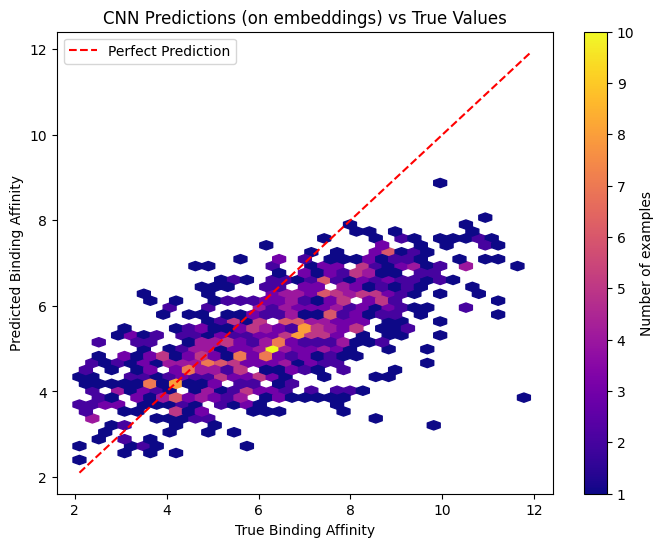

In [15]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true_list, y_pred_list, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("CNN Predictions (on embeddings) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_true_list), min(y_pred_list))
max_val = max(max(y_true_list), max(y_pred_list))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

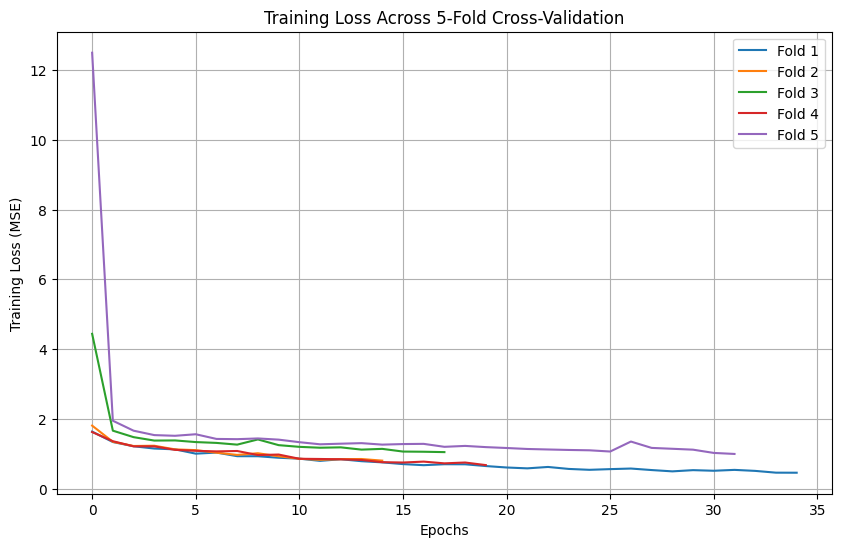

In [16]:
plt.figure(figsize=(10, 6))
for i, losses in enumerate(all_loss_curves):
    plt.plot(losses, label=f'Fold {i+1}')
plt.xlabel("Epochs")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Across 5-Fold Cross-Validation")
plt.legend()
plt.grid(True)
plt.show()